## Clase 1
### Análisis de la base de datos sobre el riesgo de diabetes

### Importación de las librerías necesarias para el análisis de la data set

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

### Se utiliza la palabra DF para definir la función que leerá toda la data set en la nomenclatura de .csv

In [38]:
df = pd.read_csv("diabetes_risk_prediction_dataset.csv")

### Utilizamos la función .head para saber todos los cabezales de la base de datos

In [39]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


#### Shape nos da el total de registros y la cantidad de columnas que tenemos

In [40]:
df.shape

(50000, 41)

### el .info nos da todos los tipos de datos de nuestros atributos

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  str    
 3   Country                     50000 non-null  str    
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    50000 non-null

### .describe nos da la descripción total de todos los campos necesarios que tenemos en nuestra data set

In [42]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


### .isnull nos da todos los registros nulos o vacíos de nuestros atributos

In [43]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

### Importamos la librería missingno y msno para la graficación de los valores nulos y la relación que tienen entre ellos

In [44]:
import missingno as msno

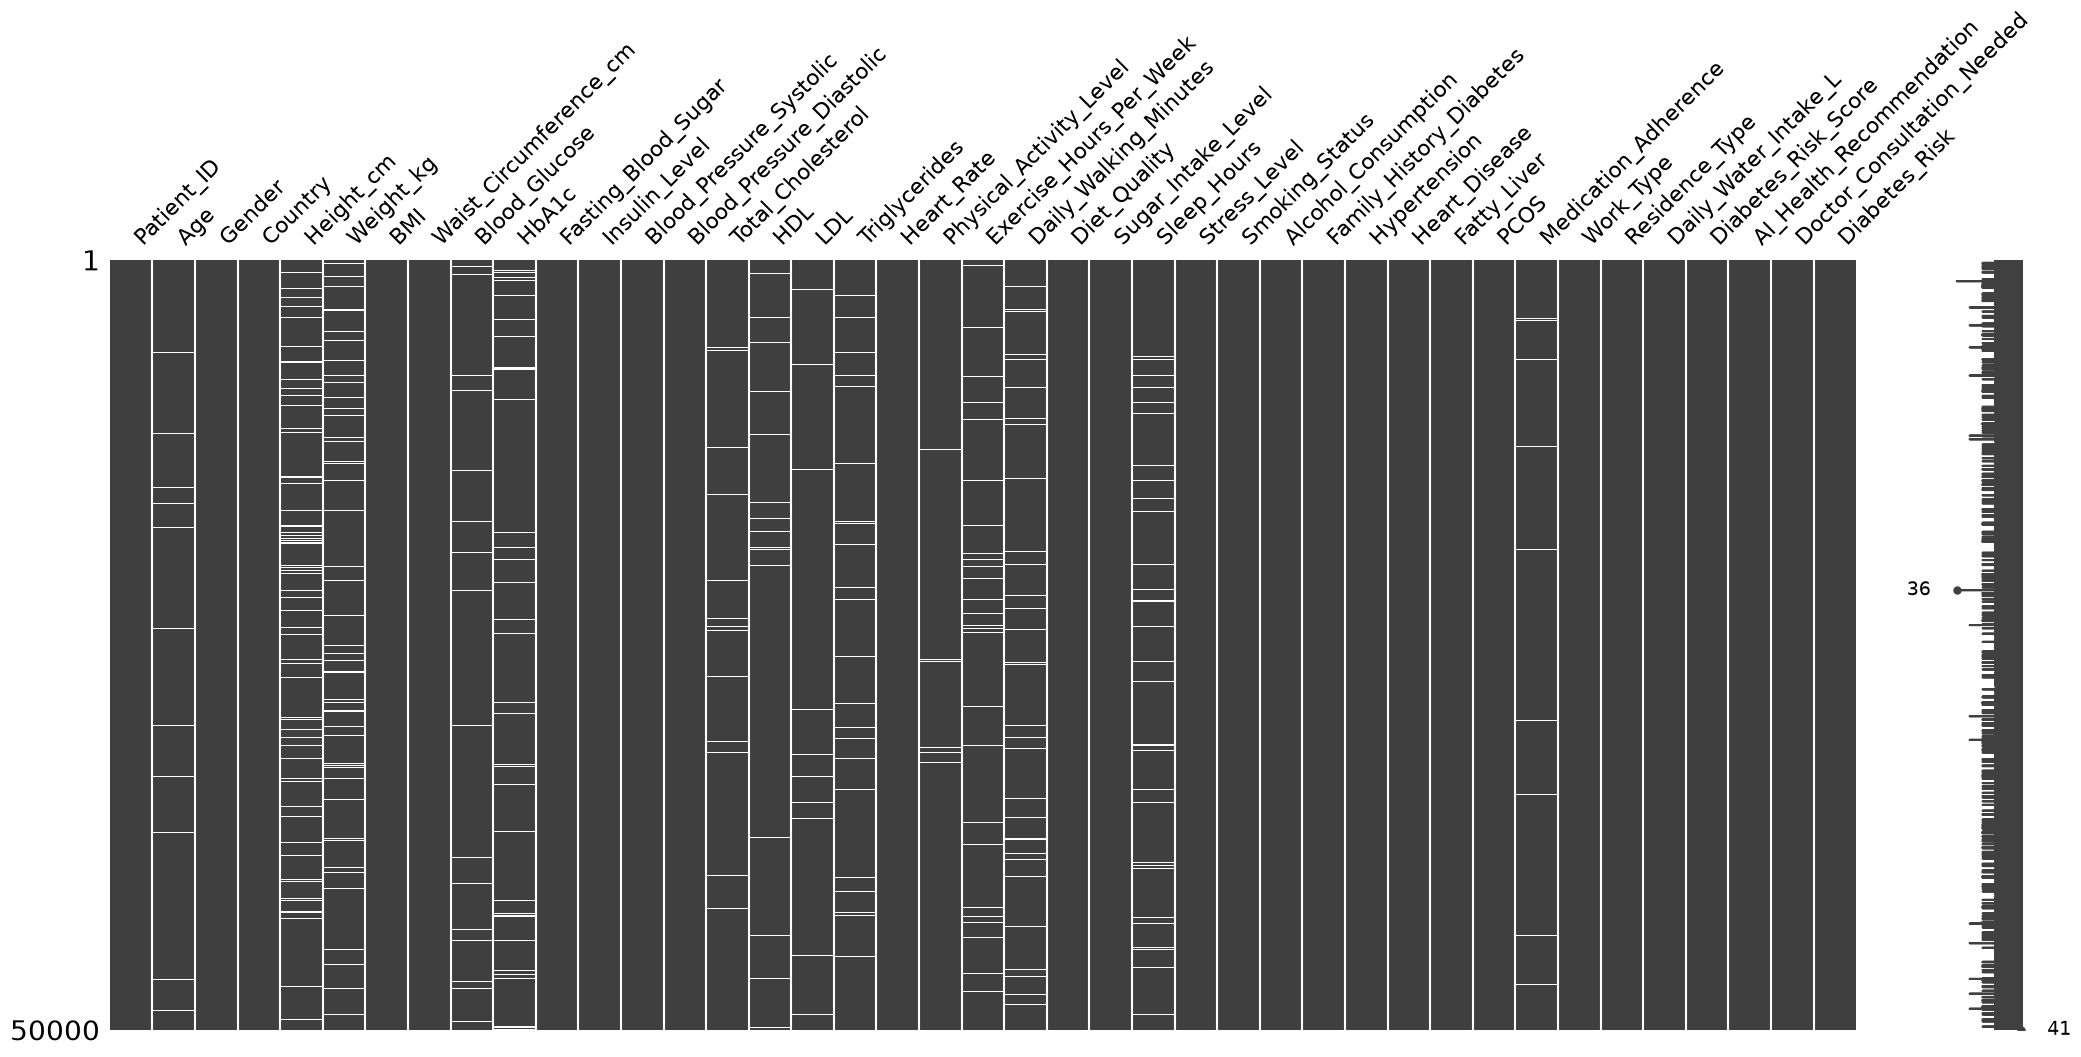

In [45]:
msno.matrix(df)
plt.show()

### Definimos la variable objetivo de estudio. En este caso la base de datos es sobre el riesgo de padecer diabetes, por lo tanto seleccionamos el atributo Edad para saber la edad de los pacientes.

In [46]:
df["Age"].fillna(
    df["Age"].median(),
    inplace=True
)

/tmp/ipykernel_6828/4028288069.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(


0        32.0
1        42.0
2        89.0
3        87.0
4        27.0
         ... 
49995    52.0
49996    53.0
49997    88.0
49998    23.0
49999    24.0
Name: Age, Length: 50000, dtype: float64

### A su vez estudiaremos el atributo nivel de actividad física de los pacientes

In [47]:
df["Physical_Activity_Level"].fillna(
    df["Physical_Activity_Level"].mode()[0],
    inplace=True
)

/tmp/ipykernel_6828/3095033521.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Physical_Activity_Level"].fillna(


0        Moderate
1            High
2            High
3            High
4        Moderate
           ...   
49995         Low
49996        High
49997    Moderate
49998         Low
49999         Low
Name: Physical_Activity_Level, Length: 50000, dtype: str

### Una vez teniendo los atributos a estudiar hacemos uso otra vez de la función .isnull para verificar los datos vacíos

In [48]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

### En este caso decimos que solo queremos saber los pacientes del sexo femenino

In [49]:
df[df["Gender"]=="Female"]

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
7,8,80.0,Female,Bangladesh,190.3,116.9,32.3,67.4,146.2,6.7,...,Yes,No,Average,Government,Urban,4.6,80,Begin Diabetes Management Plan,Yes,High
8,9,40.0,Female,United States,146.2,107.6,50.3,86.6,237.5,10.9,...,No,No,Poor,Business,Rural,3.7,79,Medical Evaluation Required,Yes,High
10,11,77.0,Female,Germany,167.1,63.2,22.6,97.9,232.2,10.9,...,No,No,Good,Private,Urban,3.6,62,Increase Physical Activity,No,Moderate
12,13,71.0,Female,Mexico,190.2,94.6,26.1,115.6,224.2,10.6,...,Yes,Yes,Average,Student,Urban,1.3,67,Immediate Lifestyle Intervention,Yes,High
18,19,69.0,Female,Nigeria,170.0,87.0,30.1,66.4,77.2,8.0,...,No,No,Average,Private,Rural,2.3,61,Increase Physical Activity,No,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49992,49993,54.0,Female,South Africa,165.6,72.0,26.3,65.3,166.7,6.2,...,Yes,No,Poor,Student,Urban,1.6,79,Immediate Lifestyle Intervention,Yes,High
49993,49994,59.0,Female,South Africa,180.2,72.9,22.5,121.4,77.8,7.7,...,No,No,Average,Government,Rural,3.0,48,Increase Physical Activity,Yes,Moderate
49994,49995,25.0,Female,Mexico,186.0,97.6,28.2,132.7,187.5,5.5,...,Yes,No,Poor,Private,Urban,3.6,60,Healthy Diet Plan,Yes,Moderate
49995,49996,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,...,No,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High


### y definimos el riesgo de la variable objetivo, queremos saber solo los pacientes con riesgo alto de diabetes

In [50]:
df[df["Diabetes_Risk"]=="High"]

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High
5,6,29.0,Male,Bangladesh,153.3,86.3,36.7,77.1,142.2,5.0,...,Yes,Yes,Poor,Retired,Urban,4.4,69,Consult Endocrinologist Immediately,Yes,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49991,49992,87.0,Other,Egypt,187.9,120.9,34.2,91.9,172.4,5.1,...,No,Yes,Good,Retired,Urban,1.6,74,Consult Endocrinologist Immediately,Yes,High
49992,49993,54.0,Female,South Africa,165.6,72.0,26.3,65.3,166.7,6.2,...,Yes,No,Poor,Student,Urban,1.6,79,Immediate Lifestyle Intervention,Yes,High
49995,49996,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,...,No,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High
49997,49998,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,...,Yes,Yes,Poor,Retired,Urban,2.6,100,Begin Diabetes Management Plan,Yes,High


### y de nuestra muestra recapitulamos un total de 50 muestras aleatorias de toda nuestra data set

In [51]:
muestra = df.sample(
    n=50,
    random_state=40
)

muestra

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
22599,22600,76.0,Male,Nigeria,193.7,76.3,20.3,118.5,126.4,6.0,...,Yes,No,Poor,Private,Urban,1.6,62,Reduce Sugar Intake,Yes,Moderate
38540,38541,23.0,Female,Egypt,157.0,120.6,48.9,71.6,245.2,8.5,...,No,Yes,Good,Retired,Urban,4.0,69,Strict Blood Sugar Monitoring,Yes,High
32995,32996,34.0,Male,Germany,190.0,92.9,25.7,133.5,164.2,5.3,...,No,Yes,Good,Student,Urban,3.1,67,Immediate Lifestyle Intervention,Yes,High
37372,37373,31.0,Other,Argentina,175.9,93.3,30.2,77.8,119.3,5.0,...,No,No,Average,Business,Rural,1.6,44,Increase Physical Activity,Yes,Moderate
26774,26775,83.0,Male,South Korea,171.9,124.4,42.1,131.8,204.4,8.1,...,Yes,Yes,Good,Retired,Rural,2.0,92,Medical Evaluation Required,Yes,High
578,579,69.0,Other,Argentina,NaN,72.1,23.9,86.6,128.2,7.3,...,Yes,Yes,Average,Student,Rural,2.7,86,Begin Diabetes Management Plan,Yes,High
34812,34813,35.0,Female,Indonesia,181.3,129.4,39.4,79.3,124.7,8.8,...,No,Yes,Poor,Student,Urban,3.2,80,Immediate Lifestyle Intervention,Yes,High
28062,28063,84.0,Female,India,187.0,95.5,27.3,114.3,118.5,10.0,...,No,No,Average,Government,Urban,2.8,88,Begin Diabetes Management Plan,Yes,High
5012,5013,18.0,Other,Pakistan,191.0,115.1,31.6,101.8,248.2,9.0,...,No,Yes,Poor,Private,Rural,3.2,90,Immediate Lifestyle Intervention,Yes,High
11968,11969,74.0,Other,Germany,173.2,90.4,30.1,92.8,241.5,6.1,...,Yes,No,Good,Student,Rural,1.7,78,Begin Diabetes Management Plan,Yes,High


### y hacemos que nos describa la muestra

In [52]:
muestra.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50.000000,49.000000,43.000000,48.000000,50.000000,50.000000,49.000000,50.000000,50.000000,50.000000,...,48.000000,49.000000,48.000000,49.000000,50.000000,48.000000,47.000000,47.000000,50.000000,50.000000
mean,25638.740000,52.857143,173.709302,91.491667,31.002000,98.726000,163.195918,8.722000,151.840000,25.730000,...,224.214583,56.816327,131.335417,213.200000,83.400000,4.841667,89.227660,6.682979,2.704000,77.600000
std,14496.732486,22.345768,15.144900,24.048726,10.416382,22.147583,47.210420,2.104542,46.477341,13.951801,...,56.003077,19.471596,49.250443,104.124963,21.271808,2.738600,49.943654,1.977077,1.079675,13.075916
min,73.000000,18.000000,147.800000,46.200000,14.600000,63.500000,78.100000,4.500000,68.200000,2.600000,...,122.100000,26.400000,51.900000,60.400000,50.000000,0.200000,9.400000,3.200000,1.000000,44.000000
25%,13053.000000,33.000000,160.500000,75.675000,23.350000,79.725000,126.300000,6.900000,110.275000,12.575000,...,179.150000,38.600000,88.150000,121.100000,63.000000,2.675000,46.150000,5.200000,1.700000,70.250000
50%,28108.000000,47.000000,173.600000,93.050000,29.600000,95.850000,158.500000,8.900000,157.550000,27.350000,...,227.850000,55.000000,134.250000,242.500000,83.500000,4.750000,96.300000,7.000000,2.650000,79.500000
75%,37752.000000,72.000000,188.050000,109.400000,36.250000,115.800000,201.200000,10.100000,188.275000,40.200000,...,272.250000,75.000000,171.275000,294.100000,98.500000,6.625000,127.800000,8.200000,3.500000,86.750000
max,48515.000000,88.000000,194.700000,129.400000,55.700000,139.200000,248.200000,12.500000,219.900000,44.300000,...,316.900000,89.200000,216.100000,399.100000,120.000000,9.900000,175.700000,10.000000,5.000000,100.000000


In [53]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


### Codificamos el atributo Gender a valores numéricos para poder analizarlo

In [54]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1,
    "Other": 2
})

In [55]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,0,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,2,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,2,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,2,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,2,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


### Hacemos que nos genere un mínimo máximo en una escala sobre la edad y el HDL (colesterol bueno)

In [56]:
scaler = MinMaxScaler()

df[["Age","HDL"]] = scaler.fit_transform(
    df[["Age","HDL"]]
)

In [57]:
df[["Age","HDL"]].head()

,Age,HDL
0,0.194444,0.232308
1,0.333333,0.163077
2,0.986111,0.109231
3,0.958333,0.567692
4,0.125000,0.190769


### y graficamos lo correspondiente

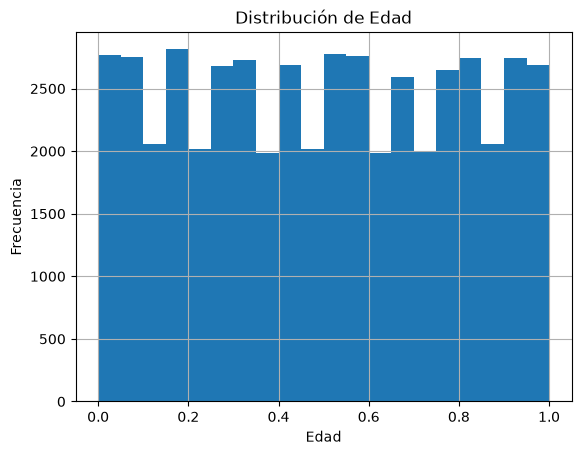

In [58]:
df["Age"].hist(
    bins=20
)

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

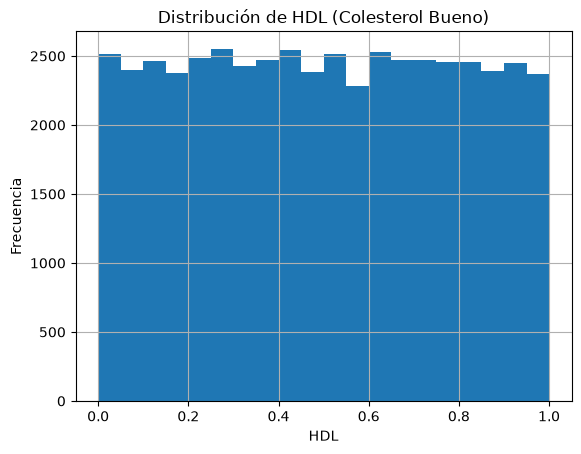

In [59]:
df["HDL"].hist(
    bins=20
)

plt.title("Distribución de HDL (Colesterol Bueno)")
plt.xlabel("HDL")
plt.ylabel("Frecuencia")

plt.show()

### Seleccionamos los atributos numéricos con los que trabajaremos

In [60]:
datos = df[
    ["Age", "HDL", "Gender", "LDL"]
]

### volvemos a generar los valores nulos o vacíos

In [61]:
datos.isnull().sum()

Age        497
HDL       1000
Gender       0
LDL       1000
dtype: int64

### y imprimimos los valores y los tipos de dato que tienen esos datos

In [62]:
print("TIPOS DE DATOS")
print(datos.dtypes)

print("\nVALORES NULOS")
print(datos.isnull().sum())

print("\nPRIMEROS REGISTROS")
print(datos.head())

TIPOS DE DATOS
Age       float64
HDL       float64
Gender      int64
LDL       float64
dtype: object

VALORES NULOS
Age        497
HDL       1000
Gender       0
LDL       1000
dtype: int64

PRIMEROS REGISTROS
        Age       HDL  Gender    LDL
0  0.194444  0.232308       0  152.3
1  0.333333  0.163077       2  110.4
2  0.986111  0.109231       2  156.7
3  0.958333  0.567692       2   63.4
4  0.125000  0.190769       2   66.5


In [63]:
datos.iloc[:10]

,Age,HDL,Gender,LDL
0,0.194444,0.232308,0,152.3
1,0.333333,0.163077,2,110.4
2,0.986111,0.109231,2,156.7
3,0.958333,0.567692,2,63.4
4,0.125000,0.190769,2,66.5
5,0.152778,0.455385,0,121.9
6,1.000000,0.935385,2,51.6
7,0.861111,NaN,1,170.0
8,0.305556,0.107692,1,198.3
9,0.763889,0.741538,2,164.0


### Restauramos la data set original para seguir trabajando

In [64]:
df = pd.read_csv("diabetes_risk_prediction_dataset.csv")

### Observamos los valores únicos del atributo Gender

In [65]:
df["Gender"].unique()

<StringArray>
['Male', 'Other', 'Female']
Length: 3, dtype: str

In [66]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1,
    "Other": 2
})

In [67]:
df["Gender"].unique()

array([0, 2, 1])

### Completamos los valores nulos de las variables que usaremos para la similitud

In [68]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["HDL"] = df["HDL"].fillna(
    df["HDL"].median()
)

df["LDL"] = df["LDL"].fillna(
    df["LDL"].median()
)

In [69]:
df[["Age","HDL","LDL"]].isnull().sum()

Age    0
HDL    0
LDL    0
dtype: int64

### Calculamos la matriz de similitud coseno entre los primeros 10 pacientes

In [70]:
from sklearn.metrics.pairwise import cosine_similarity

datos = df[
    ["Age",
     "HDL",
     "LDL",
     "Gender"]
]

similitud = cosine_similarity(
    datos.iloc[:10]
)

### Graficamos la matriz de similitud coseno

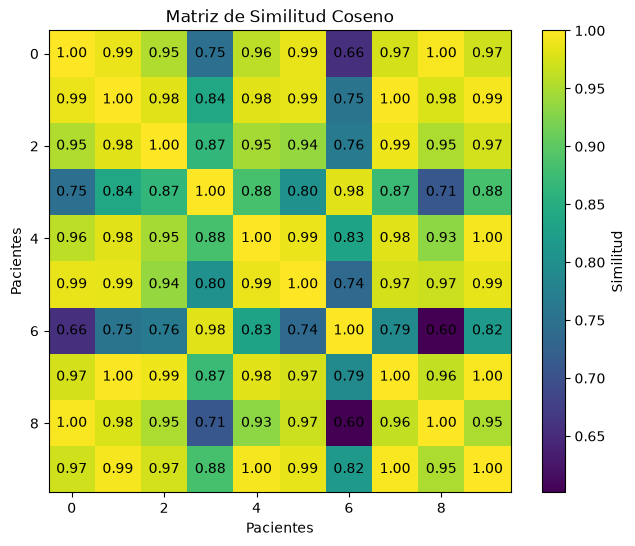

In [71]:
plt.figure(figsize=(8,6))

plt.imshow(similitud)

plt.colorbar(label="Similitud")

for i in range(similitud.shape[0]):
    for j in range(similitud.shape[1]):
        plt.text(
            j,
            i,
            f"{similitud[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de Similitud Coseno")
plt.xlabel("Pacientes")
plt.ylabel("Pacientes")

plt.show()